# Phase 6 — Routing: TSP-with-Profits

> *The model proposes, the router disposes.*

The reward model and bandit decide **what** to do at each door. None of that matters if a rep
can't physically walk the route in a shift. This notebook turns a flat list of doors — each
priced by the reward model — into a **walkable plan** that deliberately *skips* doors whose
profit doesn't justify the walk.

We mirror `src/nba/routing/` end to end:

1. **Doors & profits** — sample real (lat, lon) doors and price each by its best-action value.
2. **`DistanceEngine`** — a vectorized Haversine **travel-time** matrix (seconds, not km).
3. **Territories** — KMeans carves doors into walkable clusters so each TSP stays small.
4. **TSP-with-Profits** — OR-Tools visits dense high-profit doors and drops far, low-value ones.
5. **The knobs** — `drop_scale`, `capacity`, and time windows, and what each one does.
6. **Takeaways.**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nba.config import Settings
from nba.data.simulator import frame_to_events
from nba.reward.model import RewardModel
from nba.routing.distance import HaversineEngine
from nba.routing.territories import assign_doors, cluster_territories
from nba.routing.tsp_profits import solve_tsp_profits
from nba.schema import ACTIONS, action_cost

settings = Settings()
SEED = settings.seed
RNG = np.random.default_rng(SEED)

# === Dataset selection — toggle this one line to switch flat <-> relational ===
DATASET_MODE = "relational"  # "flat" | "relational"
_logs = {"flat": "data/logs.parquet", "relational": "data/relational/logs.parquet"}[DATASET_MODE]
_models = {"flat": "artifacts/models", "relational": "artifacts/models/relational"}[DATASET_MODE]
DATA_PATH = next((p for p in (Path(_logs), Path("..") / _logs) if p.exists()), Path(_logs))
MODEL_DIR = next((p for p in (Path(_models), Path("..") / _models) if p.exists()), Path(_models))

model = RewardModel.load(MODEL_DIR)
frame = pd.read_parquet(DATA_PATH)
contexts = [e.context for e in frame_to_events(frame)]
print("data :", DATA_PATH.resolve())
print(f"loaded model + {len(contexts):,} door contexts")

data : /home/avist/Projects/nba/data/relational/logs.parquet
loaded model + 100,000 door contexts


## 1. Doors & profits

A door's **profit** is the value of servicing it: the best action's expected reward net of its
effort cost, floored at zero (a rep can always just skip).

$$\text{profit}(x) = \max\Big(0,\ \max_a\big[\,\hat q(x, a) - \text{cost}(a)\,\big]\Big)$$

This is the *only* thing the router learns from the rest of the system — coordinates plus one
profit number per door. Everything upstream (calibration, bandit exploration, OPE) is invisible
here, which is exactly the decoupling we want.

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

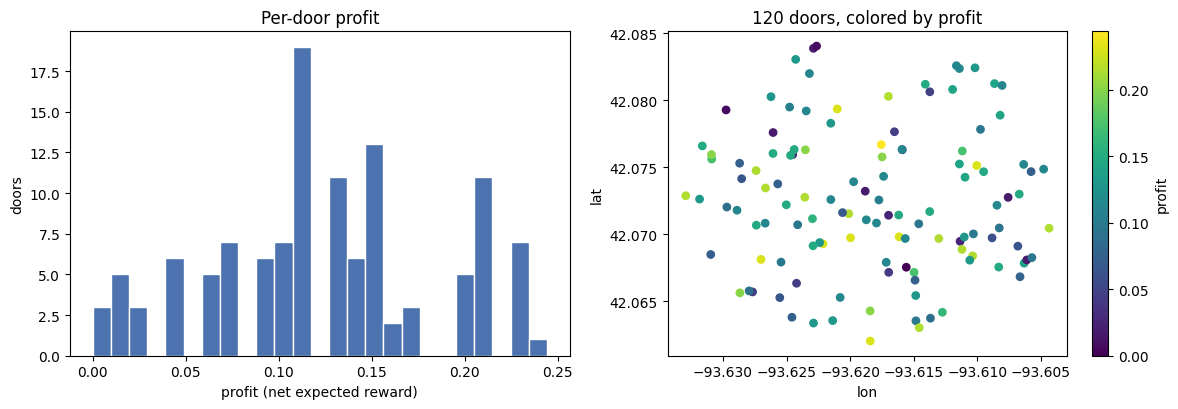

profit: min=0.000  median=0.113  max=0.244


In [2]:
# Great-circle km from one point to many (1-to-N), vectorized.
def haversine_km(center: np.ndarray, pts: np.ndarray) -> np.ndarray:
    radius = 6371.0088
    lat1, lon1 = np.radians(center)
    lat2 = np.radians(pts[:, 0])
    lon2 = np.radians(pts[:, 1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


# A rep works a dense neighborhood, not the whole city, so we pick the N doors nearest a
# randomly chosen center -- a walkable blob rather than scattered pins.
POOL = 4000
pool = [contexts[i] for i in RNG.choice(len(contexts), size=POOL, replace=False)]
pool_coords = np.array([(c.lat, c.lon) for c in pool])
center = pool_coords[RNG.integers(POOL)]

N_DOORS = 120
nearest = np.argsort(haversine_km(center, pool_coords))[:N_DOORS]
doors = [pool[i] for i in nearest]

cost_vec = np.array([action_cost(a) for a in ACTIONS])


def door_profit(ctx) -> float:
    return float(max(0.0, (model.q_all(ctx) - cost_vec).max()))


coords = [(c.lat, c.lon) for c in doors]
profits = np.array([door_profit(c) for c in doors])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2))
ax0.hist(profits, bins=25, color="#4C72B0", edgecolor="white")
ax0.set(title="Per-door profit", xlabel="profit (net expected reward)", ylabel="doors")

pts = np.array(coords)
sc = ax1.scatter(pts[:, 1], pts[:, 0], c=profits, cmap="viridis", s=28)
ax1.set(title=f"{N_DOORS} doors, colored by profit", xlabel="lon", ylabel="lat")
fig.colorbar(sc, ax=ax1, label="profit")
plt.tight_layout()
plt.show()

print(f"profit: min={profits.min():.3f}  median={np.median(profits):.3f}  max={profits.max():.3f}")

## 2. The `DistanceEngine` — travel **time**, not km

The router thinks in **seconds**, so walking speed, time windows, and dwell times all live in
one unit. `HaversineEngine` is a fully vectorized great-circle approximation: a few hundred doors
cost one NumPy broadcast, not a Python double loop. The matrix is symmetric with a zero diagonal.

`OSRMEngine` is a stub conforming to the same `DistanceEngine` protocol — when a real foot network
is available it drops in without touching a single caller.

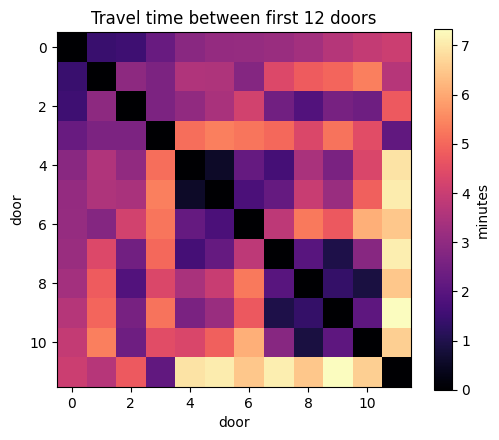

pairwise walk: median=14.3 min   max=33.0 min @ 4.5 km/h


In [3]:
engine = HaversineEngine(speed_kmh=settings.walking_speed_kmh)
time_matrix = engine.time_matrix(coords)

assert np.allclose(time_matrix, time_matrix.T)  # symmetric
assert np.allclose(np.diag(time_matrix), 0.0)  # zero diagonal

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(time_matrix[:12, :12] / 60.0, cmap="magma")
ax.set(title="Travel time between first 12 doors", xlabel="door", ylabel="door")
fig.colorbar(im, ax=ax, label="minutes")
plt.tight_layout()
plt.show()

mins = time_matrix[np.triu_indices_from(time_matrix, k=1)] / 60.0
print(
    f"pairwise walk: median={np.median(mins):.1f} min   max={mins.max():.1f} min "
    f"@ {settings.walking_speed_kmh} km/h"
)

## 3. Territories — keep each TSP small and walkable

OR-Tools' routing solver scales poorly past a few hundred nodes, and a rep's shift should stay in
one coherent neighborhood rather than zig-zag across town. `cluster_territories` runs KMeans in a
lightly rescaled lat/lon space (so 1° lon ≈ 1° lat on the ground) and produces
`ceil(n / target_size)` clusters. We target one shift's worth of doors per territory.

3 territories for 120 doors (target 40/territory)
  territory 0:  53 doors  centroid=(42.068, -93.616)
  territory 1:  29 doors  centroid=(42.077, -93.611)
  territory 2:  38 doors  centroid=(42.075, -93.626)


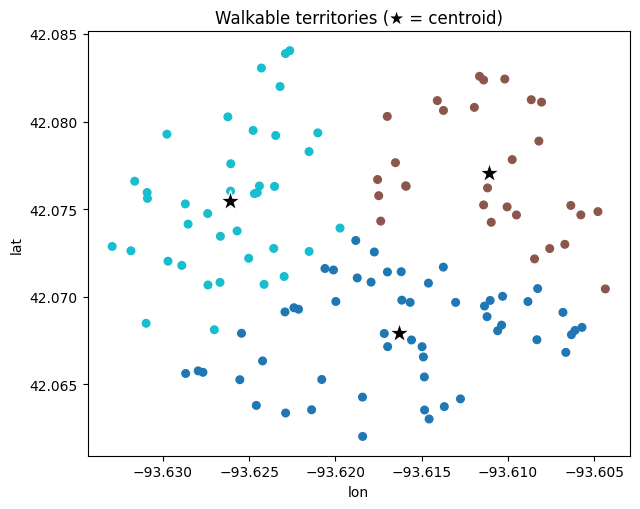

In [4]:
territories = cluster_territories(coords, target_size=settings.shift_capacity, seed=SEED)
assignment = assign_doors(coords, territories)
labels = np.array([assignment[i] for i in range(len(coords))])

print(
    f"{len(territories)} territories for {len(coords)} doors "
    f"(target {settings.shift_capacity}/territory)"
)
for t in territories:
    print(
        f"  territory {t.label}: {len(t.indices):>3} doors  centroid=({t.centroid[0]:.3f}, "
        f"{t.centroid[1]:.3f})"
    )

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.scatter(pts[:, 1], pts[:, 0], c=labels, cmap="tab10", s=30)
for t in territories:
    ax.scatter(t.centroid[1], t.centroid[0], marker="*", c="black", s=240, edgecolor="white")
ax.set(title="Walkable territories (★ = centroid)", xlabel="lon", ylabel="lat")
plt.tight_layout()
plt.show()

## 4. TSP-with-Profits — visit the worthwhile, drop the rest

Classic TSP visits *everything*. Here every non-depot door is **optional**: dropping it costs a
penalty equal to its `profit × drop_scale`. The solver minimizes
`travel time + Σ drop penalties`, so it walks to a door only when its profit beats the detour.
A far, low-profit door is cheaper to skip — exactly the field behavior we want.

We route a single territory. The depot (★) is the rep's start/end — we use the territory centroid.
Here we let the **drop penalty alone** decide who's worth visiting (no hard capacity yet).

In [5]:
chosen = max(territories, key=lambda t: len(t.indices))
sub_doors = chosen.indices

# Build a sub-problem: depot (centroid) at index 0, then the territory's doors.
sub_coords = [chosen.centroid] + [coords[i] for i in sub_doors]
sub_profits = np.concatenate([[0.0], profits[sub_doors]])
sub_tm = engine.time_matrix(sub_coords)

route = solve_tsp_profits(
    sub_coords,
    sub_profits,
    sub_tm,
    depot=0,
    capacity=None,
    drop_scale=settings.drop_scale,
    lambda_travel=settings.lambda_travel,
    service_time_s=120.0,
    time_limit_s=4.0,
    seed=SEED,
)

print(f"territory {chosen.label}: {len(sub_doors)} candidate doors")
print(f"  visited : {len(route.visited)}")
print(f"  dropped : {len(route.dropped)}")
print(f"  walk+dwell time : {route.total_time_s / 60:.1f} min")
print(
    f"  profit collected: {route.total_profit:.2f} "
    f"of {sub_profits.sum():.2f} available "
    f"({100 * route.total_profit / sub_profits.sum():.0f}%)"
)

territory 0: 53 candidate doors
  visited : 29
  dropped : 24
  walk+dwell time : 110.0 min
  profit collected: 4.09 of 6.37 available (64%)


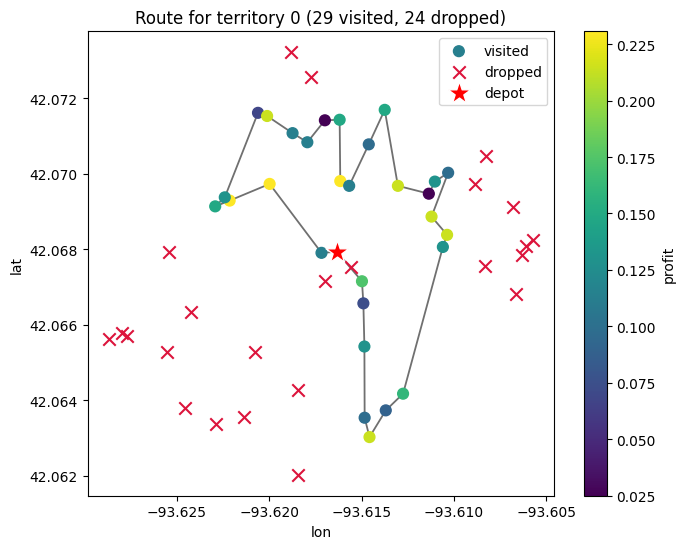

In [6]:
sub_pts = np.array(sub_coords)

fig, ax = plt.subplots(figsize=(7, 5.6))
# visited doors, colored by profit
vis = np.array(route.visited, dtype=int)
if vis.size:
    sc = ax.scatter(
        sub_pts[vis, 1],
        sub_pts[vis, 0],
        c=sub_profits[vis],
        cmap="viridis",
        s=60,
        zorder=3,
        label="visited",
    )
# dropped doors
if route.dropped:
    dr = np.array(route.dropped, dtype=int)
    ax.scatter(
        sub_pts[dr, 1], sub_pts[dr, 0], marker="x", c="crimson", s=80, zorder=3, label="dropped"
    )
# the walked path
path = sub_pts[route.order]
ax.plot(path[:, 1], path[:, 0], "-", color="#333333", lw=1.3, alpha=0.7, zorder=2)
# depot
ax.scatter(
    sub_pts[0, 1],
    sub_pts[0, 0],
    marker="*",
    c="red",
    s=300,
    edgecolor="white",
    zorder=4,
    label="depot",
)

ax.set(
    title=f"Route for territory {chosen.label} "
    f"({len(route.visited)} visited, {len(route.dropped)} dropped)",
    xlabel="lon",
    ylabel="lat",
)
ax.legend(loc="best")
if vis.size:
    fig.colorbar(sc, ax=ax, label="profit")
plt.tight_layout()
plt.show()

## 5. The knobs

### `drop_scale` — how greedy is the route?

`drop_scale` converts profit into the drop penalty (OR-Tools needs integer costs). Crank it up and
skipping a door gets expensive, so the rep visits more (and walks farther) for marginal profit.
Turn it down and the route tightens to only the easy wins. It's the dial between *coverage* and
*efficiency*.

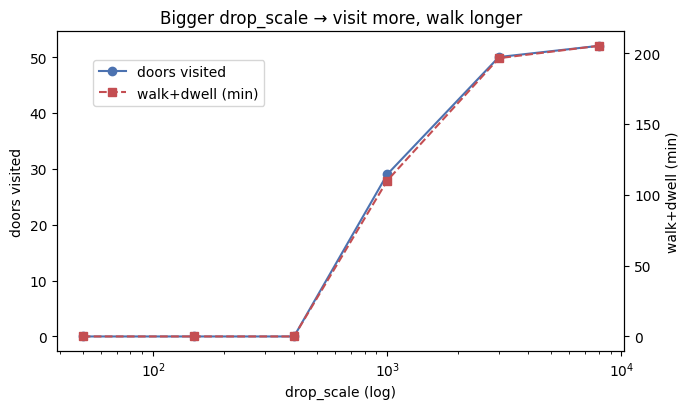

drop_scale=     50: visited=  0  time=  0.0 min  profit= 0.00
drop_scale=    150: visited=  0  time=  0.0 min  profit= 0.00
drop_scale=    400: visited=  0  time=  0.0 min  profit= 0.00
drop_scale=   1000: visited= 29  time=110.0 min  profit= 4.09
drop_scale=   3000: visited= 50  time=196.5 min  profit= 6.31
drop_scale=   8000: visited= 52  time=205.2 min  profit= 6.37


In [7]:
scales = [50.0, 150.0, 400.0, 1000.0, 3000.0, 8000.0]
rows = []
for s in scales:
    r = solve_tsp_profits(
        sub_coords,
        sub_profits,
        sub_tm,
        depot=0,
        capacity=None,
        drop_scale=s,
        lambda_travel=settings.lambda_travel,
        time_limit_s=3.0,
        seed=SEED,
    )
    rows.append((s, len(r.visited), r.total_time_s / 60, r.total_profit))

scale_arr, n_vis, t_min, prof = (np.array(c) for c in zip(*rows, strict=True))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(scale_arr, n_vis, "o-", color="#4C72B0", label="doors visited")
ax.set(xscale="log", xlabel="drop_scale (log)", ylabel="doors visited")
ax2 = ax.twinx()
ax2.plot(scale_arr, t_min, "s--", color="#C44E52", label="walk+dwell (min)")
ax2.set_ylabel("walk+dwell (min)")
ax.set_title("Bigger drop_scale → visit more, walk longer")
fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.86))
plt.tight_layout()
plt.show()

for s, nv, tm_, pf in rows:
    print(f"drop_scale={s:>7.0f}: visited={nv:>3}  time={tm_:5.1f} min  profit={pf:5.2f}")

### `capacity` — a hard cap on doors per shift

Time and `drop_scale` trade *softly*. `capacity` is a *hard* constraint: at most `k` doors get
serviced, no matter how juicy. With a tight cap the solver keeps the **highest-profit** doors and
drops the rest.

In [8]:
caps = [3, 6, 10, 15, len(sub_doors)]
for cap in caps:
    r = solve_tsp_profits(
        sub_coords,
        sub_profits,
        sub_tm,
        depot=0,
        capacity=cap,
        drop_scale=settings.drop_scale,
        time_limit_s=3.0,
        seed=SEED,
    )
    print(
        f"capacity={cap:>3}: visited={len(r.visited):>3}  "
        f"profit={r.total_profit:5.2f}  time={r.total_time_s / 60:5.1f} min"
    )

capacity=  3: visited=  3  profit= 0.46  time= 13.2 min


capacity=  6: visited=  6  profit= 1.01  time= 27.8 min


capacity= 10: visited= 10  profit= 1.37  time= 39.0 min


capacity= 15: visited= 15  profit= 2.30  time= 59.7 min


capacity= 53: visited= 29  profit= 4.09  time=110.0 min


### Time windows — "residential, 16:00–19:00"

Per-node `(open, close)` windows in seconds-of-day let the solver model when a door is reachable.
A door whose window can't be met given travel + dwell is simply dropped. Here we impose the
configured residential window on every door and start the rep at the open.

In [9]:
open_s = settings.time_window[0] * 3600
close_s = settings.time_window[1] * 3600
windows = [(open_s, close_s)] * len(sub_coords)

r_tw = solve_tsp_profits(
    sub_coords,
    sub_profits,
    sub_tm,
    depot=0,
    capacity=settings.shift_capacity,
    drop_scale=settings.drop_scale,
    time_windows=windows,
    service_time_s=120.0,
    time_limit_s=4.0,
    seed=SEED,
)

window_min = (close_s - open_s) / 60
print(
    f"window {settings.time_window[0]:02d}:00–{settings.time_window[1]:02d}:00 "
    f"= {window_min:.0f} min of daylight"
)
print(
    f"  visited={len(r_tw.visited)}  dropped={len(r_tw.dropped)}  "
    f"walk+dwell={r_tw.total_time_s / 60:.1f} min  profit={r_tw.total_profit:.2f}"
)
print("  (doors unreachable within the window are dropped automatically)")

window 16:00–19:00 = 180 min of daylight
  visited=30  dropped=23  walk+dwell=112.0 min  profit=4.09
  (doors unreachable within the window are dropped automatically)


## 6. Takeaways

- **TSP-with-Profits = optional doors with profit-sized drop penalties.** The solver trades travel
  time against profit collected, so isolated low-reward doors fall out on their own.
- **Time, not km.** A `DistanceEngine` returns seconds, so walking speed, dwell, and time windows
  compose naturally — and `OSRMEngine` can replace Haversine behind the same protocol.
- **Territories keep each instance small** and each route walkable; OR-Tools stays fast and the
  rep stays in one neighborhood.
- **Three composable knobs:** `drop_scale` dials coverage-vs-efficiency, `capacity` hard-caps the
  shift, time windows enforce when doors are reachable. Each is optional and independently testable.
- **Deterministic by construction:** fixed inputs + fixed `time_limit_s` + single thread → the same
  route every run, which is what makes the pipeline reproducible end to end.